# Análise Exploratória: Circuitos da Fórmula 1 🏎️

**Autor:** Daniel Borges
**Data:** Janeiro/2026
**Tech Stack:** Python, Pandas, Seaborn

## Objetivo do Projeto
Este projeto analisa a distribuição histórica e geográfica dos circuitos da F1. O objetivo é responder:
1. Quais países mais sediaram pistas diferentes?
2. A F1 é um esporte global ou eurocêntrico?

---

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
sns.set(style = "whitegrid")



In [32]:
#Diretórios locais
downloads_path = r"C:\Users\danie\Downloads"
file = "circuits.csv"

#Iniciando nosso Dataframe

df = pd.read_csv(os.path.join(downloads_path, file), encoding="latin1")
df.head()



,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10.0,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,NaN,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,NaN,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,MontmelÌ_,Spain,41.57000,2.26111,NaN,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,NaN,http://en.wikipedia.org/wiki/Istanbul_Park


In [33]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   circuitId   73 non-null     int64  
 1   circuitRef  73 non-null     object 
 2   name        73 non-null     object 
 3   location    73 non-null     object 
 4   country     73 non-null     object 
 5   lat         73 non-null     float64
 6   lng         73 non-null     float64
 7   alt         1 non-null      float64
 8   url         73 non-null     object 
dtypes: float64(3), int64(1), object(5)
memory usage: 5.3+ KB


circuitId      0
circuitRef     0
name           0
location       0
country        0
lat            0
lng            0
alt           72
url            0
dtype: int64

TRATAMENTO DE DADOS

In [34]:
df = df.drop(columns=["alt"])

In [35]:
contagem_paises = df['country'].value_counts()

contagem_paises.head(10)

country
USA         11
France       7
Spain        6
UK           4
Italy        3
Belgium      3
Germany      3
Canada       3
Austria      3
Portugal     3
Name: count, dtype: int64

In [36]:
df['country'] = df['country'].str.upper()

df['country'].value_counts().head()

country
USA       11
FRANCE     7
SPAIN      6
UK         4
ITALY      3
Name: count, dtype: int64

## 1. Países com maior variedade de pistas
Abaixo, analisamos quais nações possuem a maior quantidade de circuitos únicos registrados.

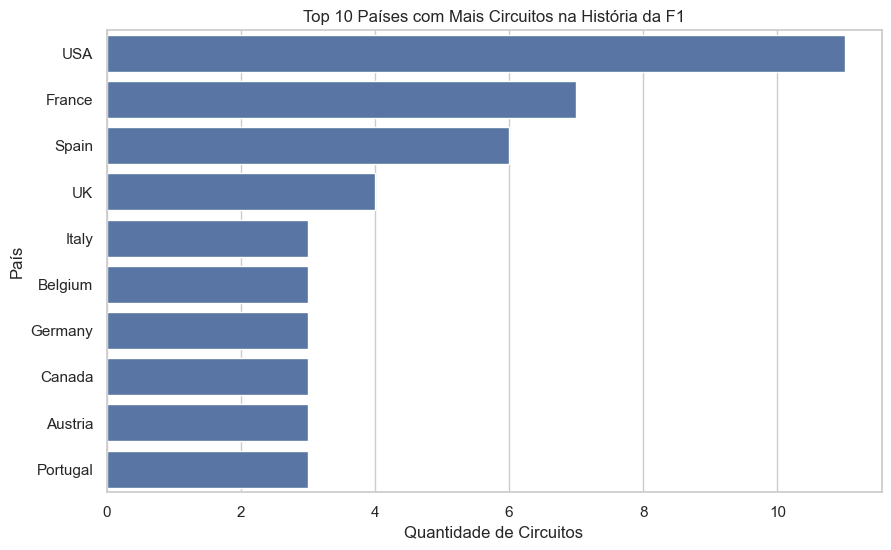

In [37]:
# Gráfico: Top 10 países com mais circuitos na história da F1

top10_paises = contagem_paises.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top10_paises.values,
    y=top10_paises.index
)

plt.title('Top 10 Países com Mais Circuitos na História da F1')
plt.xlabel('Quantidade de Circuitos')
plt.ylabel('País')
plt.show()


In [38]:
# 1. Definindo quais países são das Américas (para filtrar)
paises_americas = ['USA', 'Brazil', 'Canada', 'Mexico', 'Argentina']

# 2. Criando dois DataFrames separados (Filtros)
# df_americas: Só o que estiver na lista acima
df_americas = df[df['country'].isin(paises_americas)]

# df_mundo: Tudo o que NÃO (~) estiver na lista acima
df_mundo = df[~df['country'].isin(paises_americas)]

# 3. Salvando como arquivos CSV novos na sua pasta
# O index=False é importante pra ele não criar uma coluna extra de números
df_americas.to_csv('circuits_americas.csv', index=False)
df_mundo.to_csv('circuits_mundo.csv', index=False)

print("Arquivos criados com sucesso! Verifique sua pasta.")

Arquivos criados com sucesso! Verifique sua pasta.


# Até aqui analisamos os circuitos por país.
# Agora vamos observar a distribuição geográfica dos circuitos,
# utilizando latitude e longitude para entender a presença global da F1.


## 2. Distribuição Geográfica Global
Utilizando as coordenadas de latitude e longitude, podemos visualizar a presença física da categoria ao redor do globo.

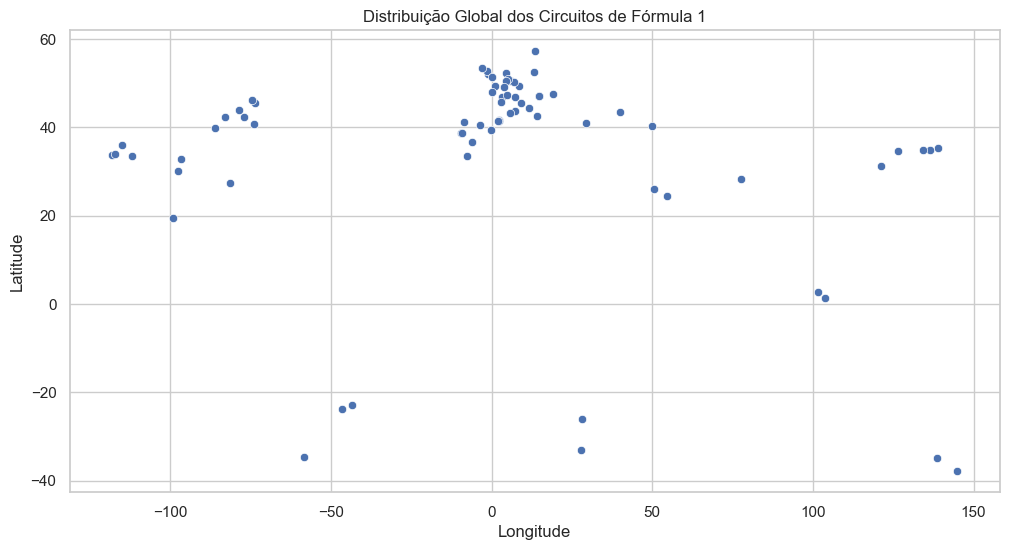

In [31]:
# Visualização da distribuição geográfica dos circuitos de F1

plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df,
    x='lng',
    y='lat'
)

plt.title('Distribuição Global dos Circuitos de Fórmula 1')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


## Conclusão:
A análise dos dados geoespaciais e históricos da F1 nos permite concluir que:

* **Eurocentrismo:** Existe uma forte concentração de circuitos na Europa, evidenciando as raízes históricas da categoria.
* **Expansão:** Apesar disso, a presença marcante nas Américas e Ásia mostra o caráter global do esporte.
* **Líderes:** Os EUA e a França se destacam como os maiores sediadores de pistas diferentes na história.